In [1]:
import os

# Root directory for all ice shelf folders
BASE_DIR = r"E:\Multi_decadal_Antarctic_ice_shelf_surface_damage_1999_2024"

# List of ice shelf folder names to process 
# Set to None to automatically scan all subfolders under BASE_DIR
ICE_SHELF_FOLDERS = ["Amery", "Amery_front", "Brunt", "Crosson", "Dotson", "Holmes", "Larsen B", "Pine Island", "Thwaites", "Totten" ]  

# Pixel resolution used as a fallback only when the GeoTIFF has no transform
DEFAULT_PIXEL_SIZE = 30.0  # metres

# Output file name
OUTPUT_EXCEL = "ice_shelf_damage_results.xlsx"
OUTPUT_FIG_AREA = "damage_area_timeseries.png"
OUTPUT_FIG_FRAC = "damage_fraction_timeseries.png"

# Figure DPI
DPI = 300

# Uncertainty band (P/R scaling) 
P1, R1 = 0.8164, 0.8410   # test set (damage)
P2, R2 = 0.8384, 0.7916   # independent image (damage)

S1 = P1 / R1
S2 = P2 / R2
S_LOW = min(S1, S2)
S_HIGH = max(S1, S2)

# DiffGF restoration-induced extra factor (UPPER bound only)
P_REST, R_REST = 0.9691, 0.9286
K_DIFFGF = P_REST / R_REST

print(f"[Uncertainty band] S_LOW={S_LOW:.4f}, S_HIGH={S_HIGH:.4f}")
print(f"[DiffGF upper-only factor] K_DIFFGF={K_DIFFGF:.4f}")

[Uncertainty band] S_LOW=0.9707, S_HIGH=1.0591
[DiffGF upper-only factor] K_DIFFGF=1.0436


In [2]:
import glob
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.unicode_minus": False,
})

print("Dependencies loaded")

Dependencies loaded


In [3]:
def find_damage_tif(year_folder):
    """Find *_damage_map.tif files in the year folder."""
    matches = glob.glob(os.path.join(year_folder, "*_damage_map.tif"))
    if matches:
        return matches[0]
    exact = os.path.join(year_folder, "damage_map.tif")
    return exact if os.path.isfile(exact) else None


def is_diffgf_path(path):
    """Check whether the path contains DiffGF, case-insensitively."""
    return "diffgf" in path.lower()


def get_pixel_area(dataset):
    """Get the area of a single pixel from the GeoTIFF transform (m²)."""
    t = dataset.transform
    if t is not None and t.a != 0:
        return abs(t.a) * abs(t.e), abs(t.a), abs(t.e)
    return DEFAULT_PIXEL_SIZE ** 2, DEFAULT_PIXEL_SIZE, DEFAULT_PIXEL_SIZE


def analyse_damage_map(tif_path):
    """Read the damage map and return a statistics dictionary, including the uncertainty band."""
    with rasterio.open(tif_path) as src:
        data = src.read(1)
        nodata = src.nodata
        pixel_area, px, py = get_pixel_area(src)

    if nodata is not None:
        valid = ~np.isnan(data) if np.isnan(nodata) else (data != nodata)
    else:
        valid = ~np.isnan(data.astype(float))

    total_px = int(np.count_nonzero(valid))
    damage_px = int(np.count_nonzero((data == 1) & valid))
    total_area = total_px * pixel_area
    damage_area = damage_px * pixel_area
    fraction = damage_area / total_area if total_area > 0 else 0.0

    # Uncertainty scaling
    diffgf = is_diffgf_path(tif_path)
    high_scale = (S_HIGH * K_DIFFGF) if diffgf else S_HIGH

    damage_area_low  = damage_area * S_LOW
    damage_area_high = damage_area * high_scale
    fraction_low  = float(np.clip(fraction * S_LOW, 0.0, 1.0))
    fraction_high = float(np.clip(fraction * high_scale, 0.0, 1.0))

    return {
        "total_pixels": total_px,
        "damage_pixels": damage_px,
        "total_area_m2": total_area,
        "damage_area_m2": damage_area,
        "total_area_km2": total_area / 1e6,
        "damage_area_km2": damage_area / 1e6,
        "damage_area_km2_low": damage_area_low / 1e6,
        "damage_area_km2_high": damage_area_high / 1e6,
        "damage_fraction": fraction,
        "damage_fraction_low": fraction_low,
        "damage_fraction_high": fraction_high,
        "is_diffgf": diffgf,
        "pixel_res_x": px,
        "pixel_res_y": py,
    }


print("Core functions defined")

Core functions defined


In [4]:
# Data collection: iterate over all ice shelves → years → damage_map.tif

if ICE_SHELF_FOLDERS is None:
    shelf_folders = sorted([
        d for d in os.listdir(BASE_DIR)
        if os.path.isdir(os.path.join(BASE_DIR, d))
    ])
else:
    shelf_folders = ICE_SHELF_FOLDERS

print(f"Ice shelves to process ({len(shelf_folders)}): {shelf_folders}\n")

results = []
for shelf_name in shelf_folders:
    shelf_path = os.path.join(BASE_DIR, shelf_name)
    if not os.path.isdir(shelf_path):
        print(f"  [WARN] Folder does not exist, skipping: {shelf_path}")
        continue

    year_dirs = sorted([
        d for d in os.listdir(shelf_path)
        if os.path.isdir(os.path.join(shelf_path, d)) and d.isdigit() and len(d) == 4
    ])

    if not year_dirs:
        print(f"  [WARN] No year folders found under {shelf_name}")
        continue

    for yr in year_dirs:
        tif = find_damage_tif(os.path.join(shelf_path, yr))
        if tif is None:
            print(f"  [WARN] No *_damage_map.tif file found in {shelf_name}/{yr}")
            continue
        print(f"  {shelf_name} / {yr}")
        stats = analyse_damage_map(tif)
        stats["ice_shelf"] = shelf_name
        stats["year"] = int(yr)
        results.append(stats)

df = pd.DataFrame(results).sort_values(["ice_shelf", "year"]).reset_index(drop=True)
print(f"\nCollected {len(df)} records in total")
df.head(10)

Ice shelves to process (10): ['Amery', 'Amery_front', 'Brunt', 'Crosson', 'Dotson', 'Holmes', 'Larsen B', 'Pine Island', 'Thwaites', 'Totten']

  Amery / 2003
  Amery / 2007
  Amery / 2009
  Amery / 2013
  Amery / 2014
  Amery / 2017
  Amery / 2018
  Amery / 2019
  Amery / 2020
  Amery / 2021
  Amery / 2022
  Amery / 2023
  Amery / 2024
  Amery_front / 2003
  Amery_front / 2007
  Amery_front / 2009
  Amery_front / 2013
  Amery_front / 2014
  Amery_front / 2017
  Amery_front / 2018
  Amery_front / 2019
  Amery_front / 2020
  Amery_front / 2021
  Amery_front / 2022
  Amery_front / 2023
  Amery_front / 2024
  Brunt / 2000
  Brunt / 2008
  Brunt / 2013
  Brunt / 2015
  Brunt / 2017
  Brunt / 2018
  Brunt / 2019
  Brunt / 2020
  Brunt / 2021
  Brunt / 2022
  Brunt / 2023
  Brunt / 2024
  Crosson / 1999
  Crosson / 2000
  Crosson / 2001
  Crosson / 2002
  Crosson / 2003
  Crosson / 2004
  Crosson / 2006
  Crosson / 2007
  Crosson / 2008
  Crosson / 2009
  Crosson / 2010
  Crosson / 2011
  Cr

,total_pixels,damage_pixels,total_area_m2,damage_area_m2,total_area_km2,damage_area_km2,damage_area_km2_low,damage_area_km2_high,damage_fraction,damage_fraction_low,damage_fraction_high,is_diffgf,pixel_res_x,pixel_res_y,ice_shelf,year
0,67496321,1973330,6.074669e+10,1.775997e+09,60746.6889,1775.9970,1724.047504,1963.033116,0.029236,0.028381,0.032315,True,30.0,30.0,Amery,2003
1,68278714,2553926,6.145084e+10,2.298533e+09,61450.8426,2298.5334,2231.299248,2540.599552,0.037404,0.036310,0.041344,True,30.0,30.0,Amery,2007
2,68691451,2413144,6.182231e+10,2.171830e+09,61822.3059,2171.8296,2108.301647,2400.552156,0.035130,0.034103,0.038830,True,30.0,30.0,Amery,2009
3,69478359,2559551,6.253052e+10,2.303596e+09,62530.5231,2303.5959,2236.213666,2439.786259,0.036840,0.035762,0.039018,False,30.0,30.0,Amery,2013
4,69701193,2564951,6.273107e+10,2.308456e+09,62731.0737,2308.4559,2240.931506,2444.933586,0.036799,0.035723,0.038975,False,30.0,30.0,Amery,2014
5,70254673,2575640,6.322921e+10,2.318076e+09,63229.2057,2318.0760,2250.270210,2455.122434,0.036661,0.035589,0.038829,False,30.0,30.0,Amery,2017
6,70447614,2388851,6.340285e+10,2.149966e+09,63402.8526,2149.9659,2087.077480,2277.073535,0.033910,0.032918,0.035914,False,30.0,30.0,Amery,2018
7,68664542,2331276,6.179809e+10,2.098148e+09,61798.0878,2098.1484,2036.775688,2222.192545,0.033952,0.032959,0.035959,False,30.0,30.0,Amery,2019
8,68879421,2531152,6.199148e+10,2.278037e+09,61991.4789,2278.0368,2211.402192,2412.716085,0.036748,0.035673,0.038920,False,30.0,30.0,Amery,2020
9,69069692,2505530,6.216272e+10,2.254977e+09,62162.7228,2254.9770,2189.016912,2388.292972,0.036275,0.035214,0.038420,False,30.0,30.0,Amery,2021


In [5]:
# Export to Excel: summary table + one separate sheet for each ice shelf

COL_HEADERS = [
    "Ice Shelf", "Year",
    "Shelf Pixels\n(count)", "Damage Pixels\n(count)",
    "Pixel Res X\n(m)", "Pixel Res Y\n(m)",
    "Shelf Area\n(m²)", "Shelf Area\n(km²)",
    "Damage Area\n(km²)", "Damage Area Low\n(km²)", "Damage Area High\n(km²)",
    "Damage Fraction", "Fraction Low", "Fraction High",
    "Is DiffGF",
]
COL_KEYS = [
    "ice_shelf", "year",
    "total_pixels", "damage_pixels",
    "pixel_res_x", "pixel_res_y",
    "total_area_m2", "total_area_km2",
    "damage_area_km2", "damage_area_km2_low", "damage_area_km2_high",
    "damage_fraction", "damage_fraction_low", "damage_fraction_high",
    "is_diffgf",
]

hdr_font = Font(name="Arial", bold=True, size=11, color="FFFFFF")
hdr_fill = PatternFill("solid", fgColor="4472C4")
hdr_align = Alignment(horizontal="center", vertical="center", wrap_text=True)
c_font = Font(name="Arial", size=10)
c_align = Alignment(horizontal="center", vertical="center")
bdr = Border(*(Side(style="thin"),) * 4)


def write_sheet(ws, sub_df):
    for c, h in enumerate(COL_HEADERS, 1):
        cell = ws.cell(row=1, column=c, value=h)
        cell.font, cell.fill, cell.alignment, cell.border = hdr_font, hdr_fill, hdr_align, bdr

    for r, (_, row) in enumerate(sub_df.iterrows(), 2):
        for c, key in enumerate(COL_KEYS, 1):
            cell = ws.cell(row=r, column=c, value=row[key])
            cell.font, cell.alignment, cell.border = c_font, c_align, bdr
            if "fraction" in key:
                cell.number_format = "0.00%"
            elif "area_m2" in key:
                cell.number_format = "#,##0"
            elif "area_km2" in key:
                cell.number_format = "#,##0.00"

    for c in range(1, len(COL_HEADERS) + 1):
        ws.column_dimensions[get_column_letter(c)].width = 18
    ws.column_dimensions["A"].width = 22
    ws.row_dimensions[1].height = 36


wb = Workbook()
ws_sum = wb.active
ws_sum.title = "Summary"
write_sheet(ws_sum, df)

for shelf in df["ice_shelf"].unique():
    ws_s = wb.create_sheet(title=shelf[:28])
    write_sheet(ws_s, df[df["ice_shelf"] == shelf])

wb.save(OUTPUT_EXCEL)
print(f"Excel saved: {OUTPUT_EXCEL}")

Excel saved: ice_shelf_damage_results.xlsx


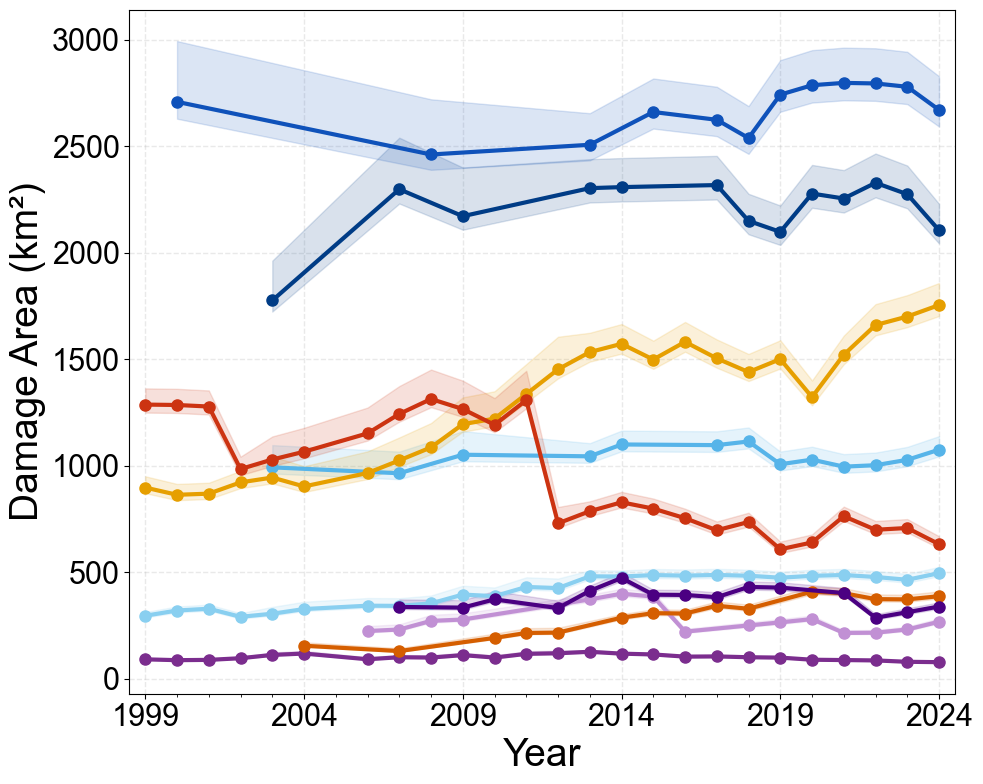

Saved: damage_area_timeseries.png


In [6]:
# Time series of damage area for each ice shelf, including the uncertainty band

shelves = df["ice_shelf"].unique()

PALETTE = [
    "#003C86",  # Amery 
    "#56B4E9",  # Amery_front 
    "#0F52BA",  # Brunt 
    "#89CFF0",  # Crosson 
    "#7B2D8E",  # Dotson 
    "#C190D4",  # Holmes 
    "#D55E00",  # Larsen B 
    "#E69F00",  # Pine Island 
    "#CC3311",  # Thwaites 
    "#4B0082",  # Totten 
]

 
colors = {s: PALETTE[i % len(PALETTE)] for i, s in enumerate(shelves)}

fig, ax = plt.subplots(figsize=(10, 8))

for i, shelf in enumerate(shelves):
    sub = df[df["ice_shelf"] == shelf].sort_values("year")
    c = colors[shelf]
    ax.fill_between(
        sub["year"], sub["damage_area_km2_low"], sub["damage_area_km2_high"],
        color=c, alpha=0.15,
    )
    ax.plot(
        sub["year"], sub["damage_area_km2"],
        color=c, linewidth=3, marker="o", markersize=8,
        label=shelf,
    )

ax.set_xlabel("Year", fontsize=28)
ax.set_ylabel("Damage Area (km²)", fontsize=28)
# ax.set_title("Ice Shelf Damage Area Time Series", fontsize=15, fontweight="bold")

# x-axis: show 1999 and 2024, with 5-year intervals in between
all_years = sorted(df["year"].unique())
y_min, y_max = min(all_years), max(all_years)
major_ticks = list(range(y_min, y_max + 1, 5))
if y_min not in major_ticks:
    major_ticks.insert(0, y_min)
if y_max not in major_ticks:
    major_ticks.append(y_max)
ax.set_xlim(y_min - 0.5, y_max + 0.5)
ax.set_xticks(major_ticks)
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.tick_params(axis="x", labelsize=22)
ax.tick_params(axis="y", labelsize=22)

# ax.yaxis.grid(True, linestyle="-", alpha=0.15, linewidth=0.5)
# ax.xaxis.grid(False)
# ax.xaxis.grid(True, linestyle="-", alpha=0.15, linewidth=0.5)
ax.grid(True, axis="both", linestyle="--", linewidth=1, alpha=0.28, zorder=1)
ax.set_axisbelow(True)

ax.get_legend() and ax.get_legend().remove()  # No legend inside the figure
fig.tight_layout()
fig.savefig(OUTPUT_FIG_AREA, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_FIG_AREA}")

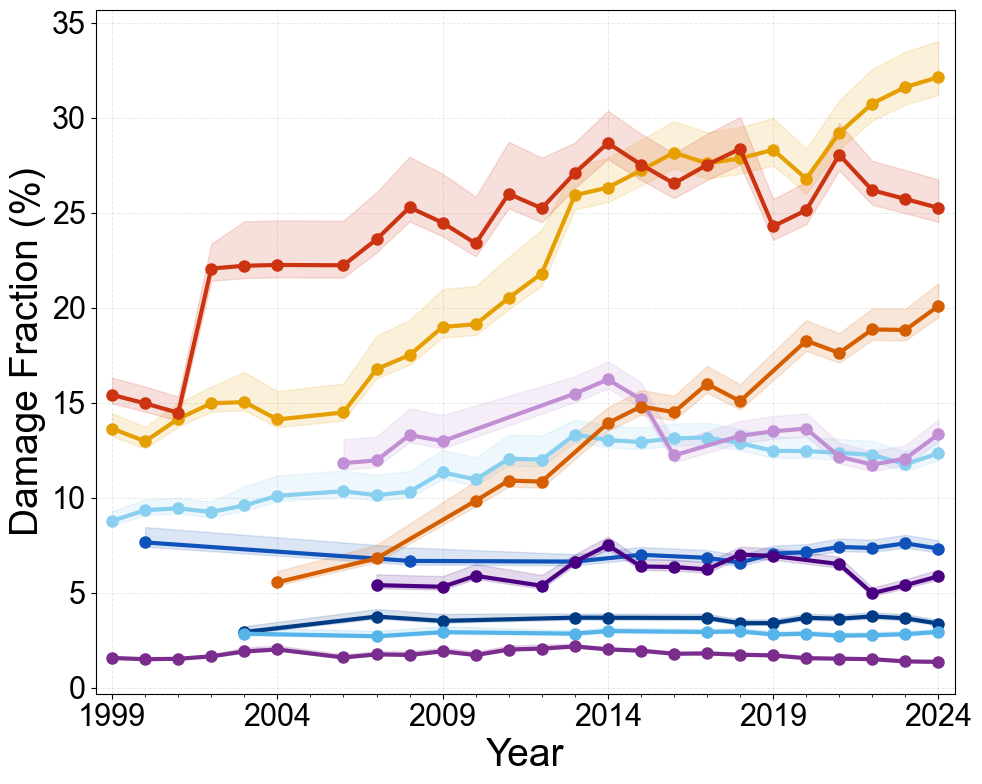

Saved: damage_fraction_timeseries.png


In [7]:
# Time series of damage percentage for each ice shelf, including the uncertainty band

fig, ax = plt.subplots(figsize=(10, 8))

for i, shelf in enumerate(shelves):
    sub = df[df["ice_shelf"] == shelf].sort_values("year")
    c = colors[shelf]
    ax.fill_between(
        sub["year"], sub["damage_fraction_low"] * 100, sub["damage_fraction_high"] * 100,
        color=c, alpha=0.15,
    )
    ax.plot(
        sub["year"], sub["damage_fraction"] * 100,
        color=c, linewidth=3, marker="o", markersize=8,
        label=shelf,
    )

ax.set_xlabel("Year", fontsize=28)
ax.set_ylabel("Damage Fraction (%)", fontsize=28)
# ax.set_title("Ice Shelf Damage Fraction Time Series", fontsize=15, fontweight="bold")

ax.set_xlim(y_min - 0.5, y_max + 0.5)
ax.set_xticks(major_ticks)
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.tick_params(axis="x", labelsize=22)
ax.tick_params(axis="y", labelsize=22)

# ax.yaxis.grid(True, linestyle="-", alpha=0.15, linewidth=0.5)
# ax.xaxis.grid(False)
ax.grid(True, axis="both", linestyle="--", linewidth=0.7, alpha=0.28, zorder=1)
ax.set_axisbelow(True)

ax.get_legend() and ax.get_legend().remove()
fig.tight_layout()
fig.savefig(OUTPUT_FIG_FRAC, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_FIG_FRAC}")

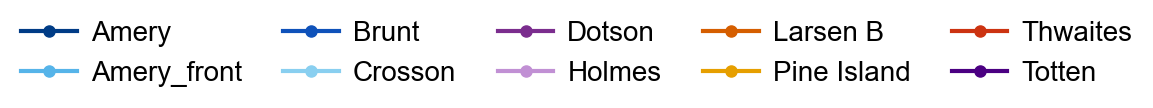

Saved: legend.png


In [8]:
# Generate a separate legend figure

fig_leg, ax_leg = plt.subplots(figsize=(8, 1.2))
ax_leg.set_axis_off()

handles = []
for i, shelf in enumerate(shelves):
    h, = ax_leg.plot([], [], color=colors[shelf], linewidth=3, marker="o", markersize=8, label=shelf)
    handles.append(h)

ax_leg.legend(
    handles=handles, loc="center", ncol=5,
    prop={"family": "Arial", "size": 20},
    frameon=False, columnspacing=1.5, handletextpad=0.5,
)
fig_leg.tight_layout()
fig_leg.savefig("legend.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved: legend.png")

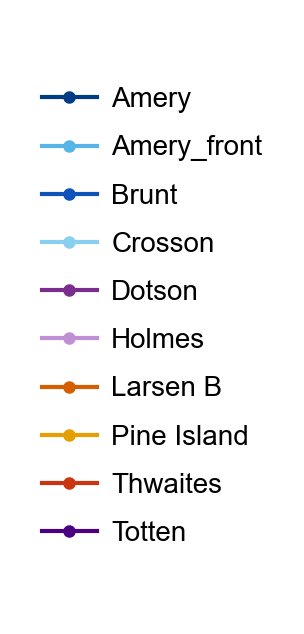

Saved: legend_vertical.png


In [9]:
# Generate a separate vertical legend figure

fig_leg, ax_leg = plt.subplots(figsize=(3.2, 6.5))
ax_leg.set_axis_off()

handles = []
for i, shelf in enumerate(shelves):
    h, = ax_leg.plot(
        [], [], 
        color=colors[shelf],
        linewidth=3,
        marker="o",
        markersize=8,
        label=shelf
    )
    handles.append(h)

ax_leg.legend(
    handles=handles,
    loc="center",
    ncol=1,   
    prop={"family": "Arial", "size": 20},
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.5,
    labelspacing=0.8,  
    borderaxespad=0.0,
)

fig_leg.tight_layout()
fig_leg.savefig("legend_vertical.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved: legend_vertical.png")